# RavenStack SaaS — Churn & Revenue Analysis

This project analyzes customer churn and revenue performance for a SaaS company using SQL, Python, and Power BI.

The objective is to identify the key drivers of churn, quantify revenue impact, and provide actionable insights for improving retention.

In [73]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

print('libraries loaded')

libraries loaded


## Data Sources

The analysis uses pre-aggregated datasets generated from SQL queries, along with raw transactional tables for additional context.

All datasets are loaded from structured CSV exports to ensure reproducibility.

In [74]:
# load all CSV exports from SQL
base_path = "data/sql_outputs/"

churn_by_plan = pd.read_csv(base_path + "03_churn_rate.csv")
churn_reasons_summary = pd.read_csv(base_path + "04_churn_reasons_summary.csv")
churn_reasons_by_plan = pd.read_csv(base_path + "04_churn_reasons.csv")
support_vs_churn = pd.read_csv(base_path + "05_support_vs_churn.csv")
feature_usage = pd.read_csv(base_path + "06_feature_usage.csv")
silent_churn = pd.read_csv(base_path + "07_silent_churn.csv")
mrr_trend = pd.read_csv(base_path + "08_mrr.csv")
cohort = pd.read_csv(base_path + "09_cohort.csv")

print("All SQL export files loaded")

All SQL export files loaded


In [75]:
# load original raw data
base_path = "data/raw/"
accounts = pd.read_csv(base_path + "ravenstack_accounts.csv")
subscriptions = pd.read_csv(base_path + "ravenstack_subscriptions.csv")
churn_events = pd.read_csv(base_path + "ravenstack_churn_events.csv")
support_tickets = pd.read_csv(base_path + "ravenstack_support_tickets.csv")

print('raw files loaded')

raw files loaded


In [76]:
# check all files loaded correctly
print('churn_by_plan:', churn_by_plan.shape)
print('churn_reasons_summary:', churn_reasons_summary.shape)
print('churn_reasons_by_plan:', churn_reasons_by_plan.shape)
print('support_vs_churn:', support_vs_churn.shape)
print('feature_usage:', feature_usage.shape)
print('silent_churn:', silent_churn.shape)
print('mrr_trend:', mrr_trend.shape)
print('cohort:', cohort.shape)
print()
print('accounts:', accounts.shape)
print('subscriptions:', subscriptions.shape)
print('churn_events:', churn_events.shape)
print('support_tickets:', support_tickets.shape)

print("\nColumns in churn_by_plan:", churn_by_plan.columns.tolist())
print("Columns in mrr_trend:", mrr_trend.columns.tolist())

churn_by_plan: (3, 4)
churn_reasons_summary: (6, 2)
churn_reasons_by_plan: (18, 3)
support_vs_churn: (2, 4)
feature_usage: (20, 4)
silent_churn: (3, 3)
mrr_trend: (24, 3)
cohort: (300, 3)

accounts: (500, 10)
subscriptions: (5000, 14)
churn_events: (600, 9)
support_tickets: (2000, 9)

Columns in churn_by_plan: ['plan_tier', 'total', 'churned', 'churn_rate_pct']
Columns in mrr_trend: ['month', 'new_subs', 'new_mrr']


In [77]:
churn_by_plan.head()

,plan_tier,total,churned,churn_rate_pct
0,Enterprise,154,34,22.1
1,Basic,168,37,22.0
2,Pro,178,39,21.9


## Churn Overview

This section examines overall churn rates across different plan tiers to determine whether customer churn is concentrated within specific segments.

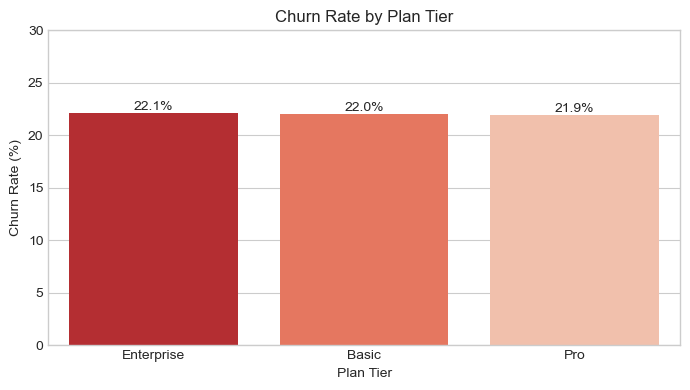

In [78]:
# churn rate by plan tier
# objective: compare churn rates across subscription tiers
# insight focus: determine whether churn is driven by pricing/plan differences

# sort from highest to lowest so the most impacted segment appears first
churn_by_plan = churn_by_plan.sort_values('churn_rate_pct', ascending=False)

# create a red gradient where darker shades represent higher churn
# reversing ensures the highest churn tier is visually emphasized
colors = sns.color_palette("Reds", n_colors=len(churn_by_plan))[::-1]

plt.figure(figsize=(7, 4))

# bar chart comparing churn rates across plan tiers
sns.barplot(
    data=churn_by_plan,
    x='plan_tier',
    y='churn_rate_pct',
    hue='plan_tier',
    palette=colors,
    legend=False
)

# chart labeling for clarity
plt.title('Churn Rate by Plan Tier')
plt.xlabel('Plan Tier')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 30)

# annotate bars with exact churn percentages for quick interpretation
for i, row in enumerate(churn_by_plan['churn_rate_pct']):
    plt.text(
        i,
        row + 0.3,
        f"{row}%",
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Churn Drivers

To understand why customers churn, we analyze the most common churn reasons and evaluate whether these reasons vary across plan tiers.

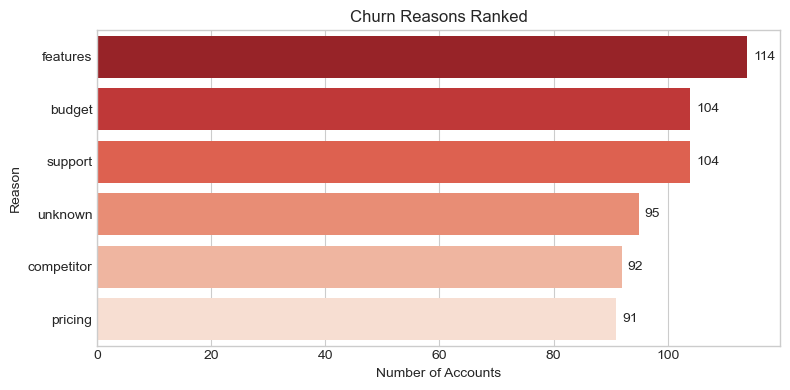

In [79]:
# churn reasons ranked
# group by churn reason and sum totals across all plan tiers
reasons_ranked = churn_reasons_by_plan.groupby('reason_code', as_index=False)['total'].sum()

# sort from highest to lowest so the top reason appears first
reasons_ranked = reasons_ranked.sort_values('total', ascending=False)

# create a red gradient palette and reverse it
# darkest red goes to the highest value at the top
colors = sns.color_palette("Reds", n_colors=len(reasons_ranked))[::-1]

plt.figure(figsize=(8, 4))

sns.barplot(
    data=reasons_ranked,
    x='total',
    y='reason_code',
    hue='reason_code',
    palette=colors,
    legend=False
)

plt.title('Churn Reasons Ranked')
plt.xlabel('Number of Accounts')
plt.ylabel('Reason')

for i, row in enumerate(reasons_ranked['total']):
    plt.text(row + 1, i, str(row), va='center', fontsize=10)

plt.tight_layout()
plt.show()

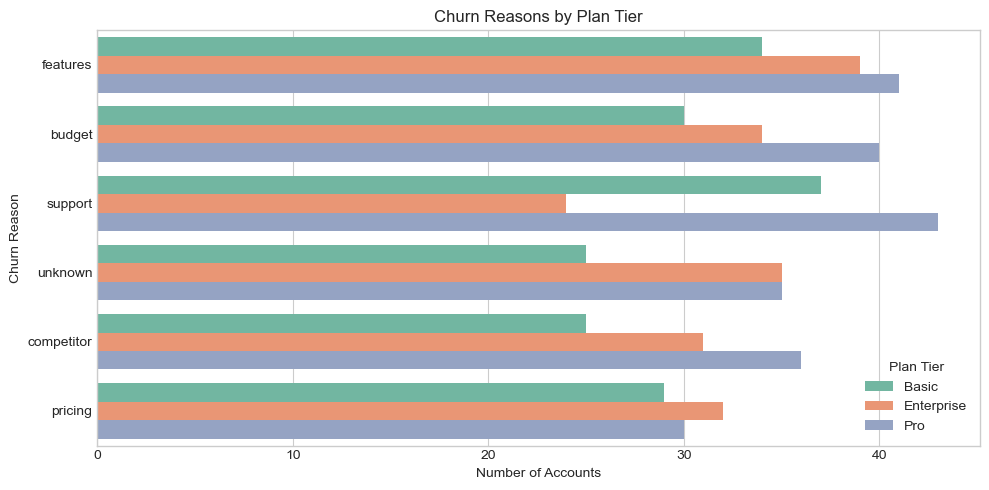

In [80]:
# churn reasons by plan tier
# this chart compares the main churn reasons across Basic, Pro, and Enterprise plans

# order reasons by total churn impact across all plan tiers
reason_order = (
    churn_reasons_by_plan.groupby('reason_code')['total']
    .sum()
    .sort_values(ascending=False)
    .index
)

# create the chart
plt.figure(figsize=(10, 5))

sns.barplot(
    data=churn_reasons_by_plan,
    x='total',
    y='reason_code',
    hue='plan_tier',
    order=reason_order,
    palette='Set2'
)

# add title and labels
plt.title('Churn Reasons by Plan Tier')
plt.xlabel('Number of Accounts')
plt.ylabel('Churn Reason')

# add legend
plt.legend(title='Plan Tier')

# clean layout
plt.tight_layout()
plt.show()

## Revenue Impact

Churn has direct financial implications. This section evaluates revenue at risk due to inactive users and examines overall revenue growth trends over time.

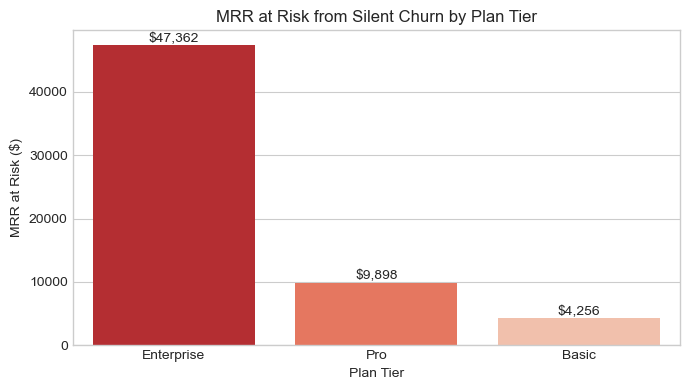

In [81]:
# silent churn: MRR at risk by plan tier
# show how much recurring revenue is at risk from inactive (but still paying) customers

# sort data so the highest revenue risk appears first
silent_churn_sorted = silent_churn.sort_values('mrr_at_risk', ascending=False)

# create a red gradient palette and reverse it
# darkest red will represent the highest revenue risk
colors = sns.color_palette("Reds", n_colors=len(silent_churn_sorted))[::-1]

plt.figure(figsize=(7, 4))

# create bar chart
sns.barplot(
    data=silent_churn_sorted,
    x='plan_tier',
    y='mrr_at_risk',
    hue='plan_tier',
    palette=colors,
    legend=False
)

# add chart title and axis labels
plt.title('MRR at Risk from Silent Churn by Plan Tier')
plt.xlabel('Plan Tier')
plt.ylabel('MRR at Risk ($)')

# add value labels above each bar for readability
for i, row in enumerate(silent_churn_sorted['mrr_at_risk']):
    plt.text(
        i,
        row + 500,
        f"${row:,.0f}",
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

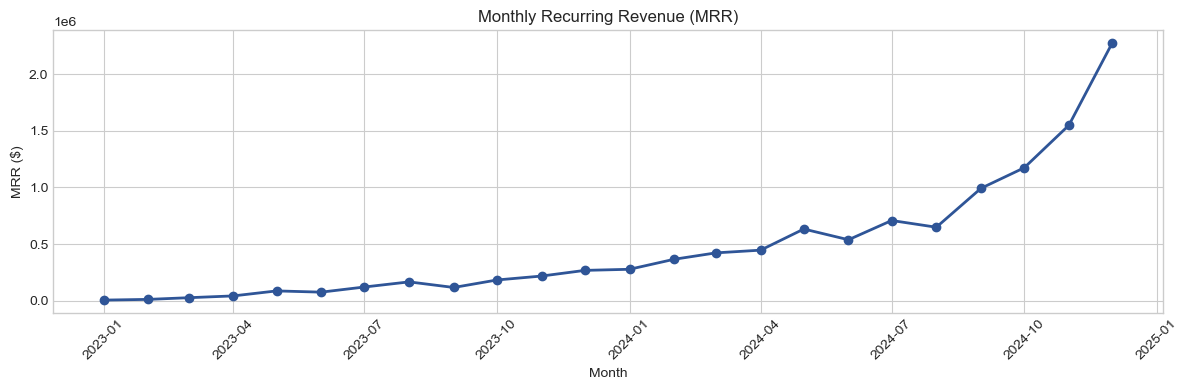

In [84]:
# MRR trend over time
# convert month column to datetime so the line chart plots correctly

mrr_trend['month'] = pd.to_datetime(mrr_trend['month'])

plt.figure(figsize=(12, 4))

plt.plot(
    mrr_trend['month'],
    mrr_trend['new_mrr'],
    marker='o',
    linewidth=2,
    color='#2F5597'
)

plt.title('Monthly Recurring Revenue (MRR)')
plt.xlabel('Month')
plt.ylabel('MRR ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Behavioral Analysis

Customer behavior provides insight into retention patterns. This section compares feature usage between retained and churned users to identify engagement signals that reduce churn.

In [85]:
# feature usage: churned vs retained
# compare average feature usage between retained and churned customers

# group by feature and churn status, then reshape to wide format
feature_compare = feature_usage.groupby(
    ['feature_name', 'churn_flag']
)['avg_usage'].mean().unstack()

# inspect the columns created by unstack
print("Original columns:", feature_compare.columns.tolist())

# rename churn flag columns safely depending on actual values
feature_compare = feature_compare.rename(columns={
    False: 'Retained',
    True: 'Churned',
    'False': 'Retained',
    'True': 'Churned',
    0: 'Retained',
    1: 'Churned'
})

print("Renamed columns:", feature_compare.columns.tolist())

# fill missing columns if one group is absent for a feature
if 'Retained' not in feature_compare.columns:
    feature_compare['Retained'] = 0

if 'Churned' not in feature_compare.columns:
    feature_compare['Churned'] = 0

# calculate difference in average usage
# positive values mean retained users engage more than churned users
feature_compare['difference'] = feature_compare['Retained'] - feature_compare['Churned']

# keep the top 10 features where retained users show higher engagement
top_sticky = feature_compare.sort_values('difference', ascending=False).head(10)

top_sticky

Original columns: [False, True]
Renamed columns: ['Retained', 'Churned']


churn_flag,Retained,Churned,difference
feature_name,,,
feature_10,10.19,9.69,0.50
feature_11,10.23,9.95,0.28
feature_1,10.19,9.92,0.27
feature_18,10.00,9.76,0.24
feature_16,10.11,10.01,0.10
feature_12,9.91,9.92,-0.01
feature_13,9.93,10.09,-0.16
feature_15,10.28,10.53,-0.25
feature_14,9.71,10.09,-0.38


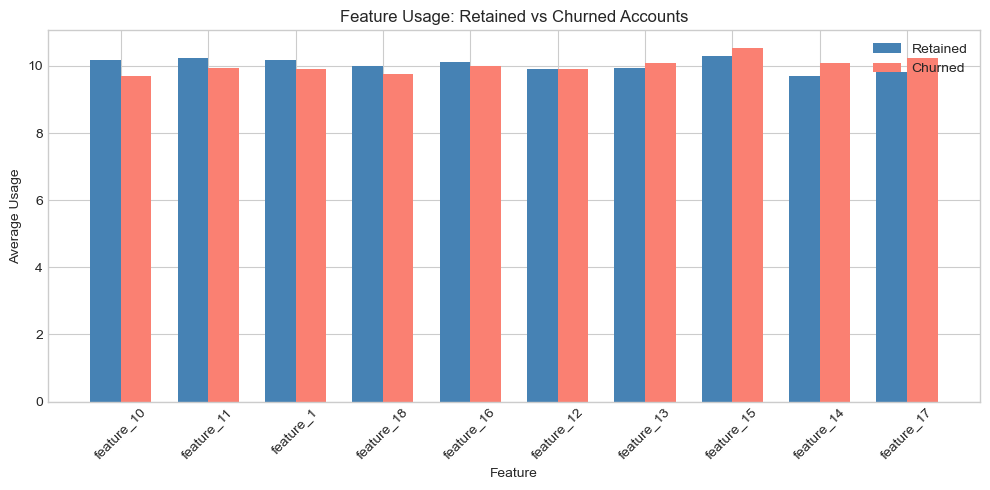

In [86]:
# plot top sticky features
# visualize features where retained users engage more than churned users

top_sticky_reset = top_sticky.reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(top_sticky_reset))
width = 0.35

ax.bar(
    [i - width/2 for i in x],
    top_sticky_reset['Retained'],
    width,
    label='Retained',
    color='steelblue'
)

ax.bar(
    [i + width/2 for i in x],
    top_sticky_reset['Churned'],
    width,
    label='Churned',
    color='salmon'
)

ax.set_title('Feature Usage: Retained vs Churned Accounts')
ax.set_xlabel('Feature')
ax.set_ylabel('Average Usage')
ax.set_xticks(list(x))
ax.set_xticklabels(top_sticky_reset['feature_name'], rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

## Retention Over Time

Cohort analysis is used to evaluate how customer retention evolves over time, providing a deeper understanding of long-term engagement trends.

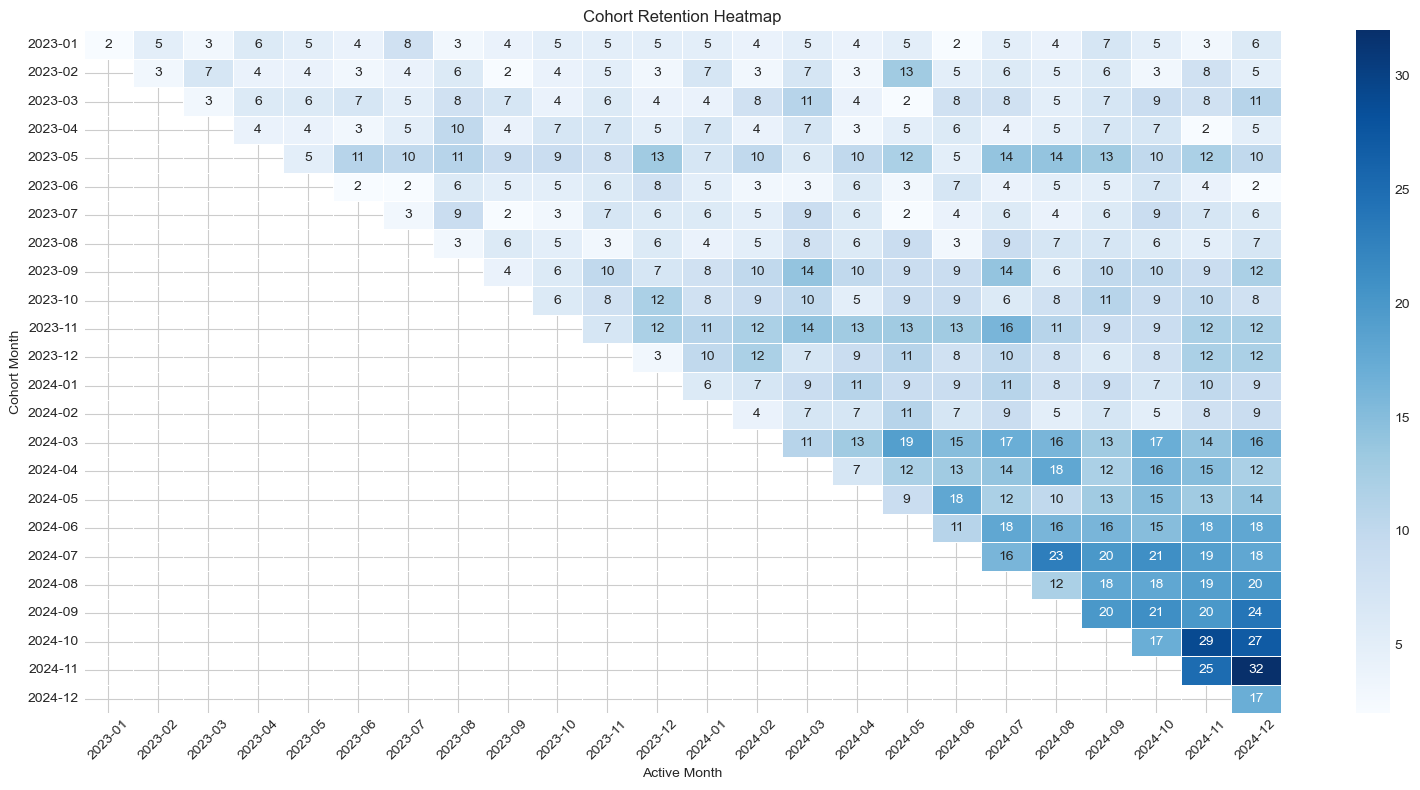

In [87]:
# cohort retention heatmap
# show customer activity over time by signup cohort

cohort_pivot = cohort.pivot_table(
    index='cohort_month',
    columns='active_month',
    values='accounts_active'
)

plt.figure(figsize=(16, 8))

sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Cohort Retention Heatmap')
plt.xlabel('Active Month')
plt.ylabel('Cohort Month')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Key Insights

- Churn rate remains consistent (~22%) across all plan tiers, indicating pricing or plan level is not the primary driver.
- Feature limitations are the dominant cause of churn, affecting customers across all segments.
- Monthly Recurring Revenue (MRR) increased significantly from early 2023 to late 2024, showing strong growth despite churn.
- Silent churn represents hidden revenue risk from disengaged but paying users.
- Retained users consistently show higher feature engagement, suggesting product usage is a key retention driver.
- Cohort trends indicate that early engagement plays a critical role in long-term retention.

## Conclusion

The analysis suggests that improving product features and increasing user engagement should be prioritized over pricing changes to reduce churn and sustain revenue growth.